# Benchmark of ML models

### Decision tree regressor

In [1]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from pandas import read_csv

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [18]:
# Taken from https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py

#df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_smote_training_data.csv')
#X = df.drop(columns = ['UHI Index'])
X = df.drop(columns = ['UHI Index binned'])
#y = df['UHI Index']
y = df['UHI Index binned']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rgr = DecisionTreeRegressor(random_state = 0)
path = rgr.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

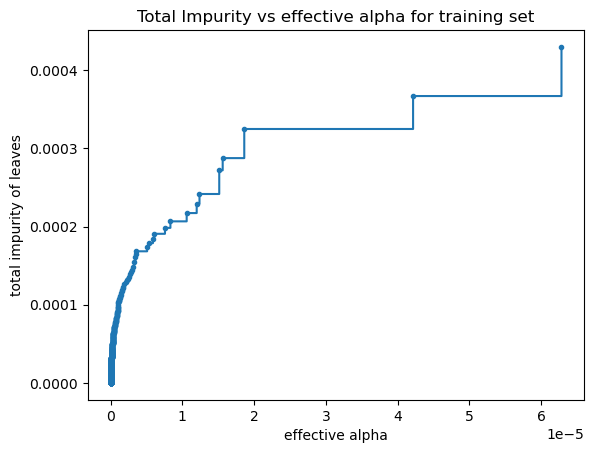

In [19]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", markersize = 3.0, drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [20]:
rgrs = []
#for ccp_alpha in ccp_alphas[-14:]:
for ccp_alpha in ccp_alphas[50:]:
    rgr = DecisionTreeRegressor(random_state = 0, ccp_alpha = ccp_alpha, max_features = 0.3, min_samples_leaf = 0.01)
    rgr.fit(X_train, y_train)
    rgrs.append(rgr)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(rgrs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.00023854053649389085


In [21]:
total_sum = 0.0

for rgr in rgrs:
    total_sum += rgr.feature_importances_
    
# Compute the mean of the feature importances
total_sum = total_sum/len(total_sum)

In [22]:
df_names = read_csv('../data/final_datasets/raw_datasets/raw_reduced_training_data.csv')
corr = df_names.corr(method = 'spearman')

In [23]:
for column, correlation, importance in zip(df_names.columns[:-1], corr['UHI Index'].values[:-1], total_sum):
    print(column, correlation, importance)

gndvi_median_res10 -0.23242072169639502 0.0
datt1_median_res10 -0.10112222266059069 0.0
fs_median_res10 0.23669203740624217 0.039427087070142114
siwsi_median_res10 -0.23756384399757405 0.0
ndmi_median_res10 -0.19692658420060125 0.0
si_median_res10 0.14768744061173628 0.0
w_median_res10 -0.13322188268910745 0.0
evi_median_res10 -0.20325645482723342 0.0
B2_median_res10 0.17331527364580235 0.0
B3_median_res10 0.1707866849907093 0.0
B4_median_res10 0.1721538369503773 0.0
B5_median_res10 0.16861792634929842 0.17524167172807104
B7_median_res10 -0.10985123255260303 0.09092145323859424
B8_median_res10 -0.1322424711376458 0.0
B8A_median_res10 -0.12267888198808166 0.2905409403676718
B11_median_res10 0.10195918314314867 0.0
B12_median_res10 0.18389258468059266 0.0
gndvi_median_res100 -0.26960740029197466 0.0
fs_median_res100 0.2837008754309153 1.0628328898769464
siwsi_median_res100 -0.24280627620865802 0.0
ndmi_median_res100 -0.2106285087572004 0.0
si_median_res100 0.20302068066423937 0.329501546

Los que más suman son: LST, Polygon density y Air temperature at surface

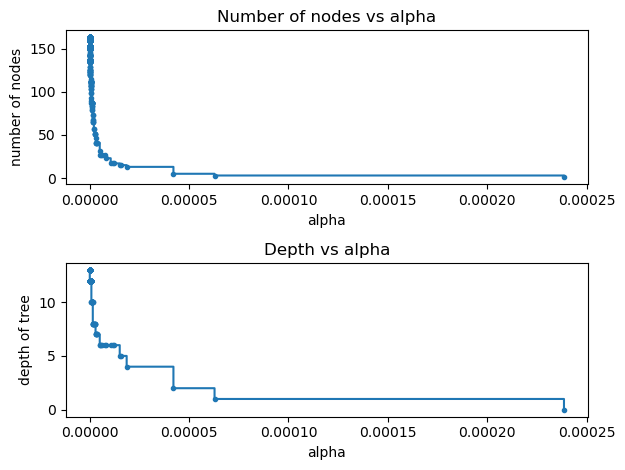

In [24]:
ccp_alphas = ccp_alphas[50:]

node_counts = [rgr.tree_.node_count for rgr in rgrs]
depth = [rgr.tree_.max_depth for rgr in rgrs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

ax[1].plot(ccp_alphas, depth, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

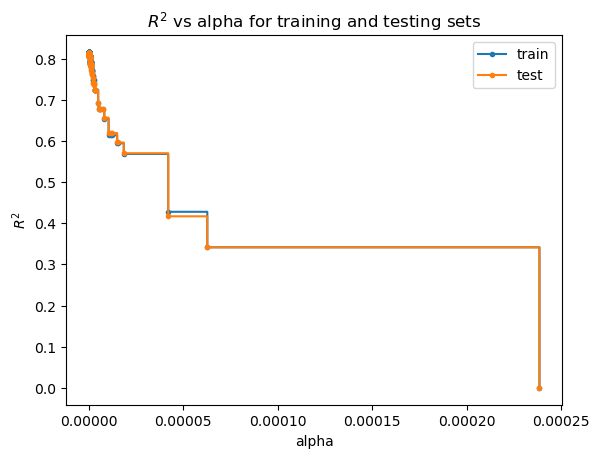

In [25]:
train_predictions = [rgr.predict(X_train) for rgr in rgrs]
test_predictions = [rgr.predict(X_test) for rgr in rgrs]

r2_train = [r2_score(y_train, y_pred) for y_pred in train_predictions]
r2_test = [r2_score(y_test, y_pred) for y_pred in test_predictions]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

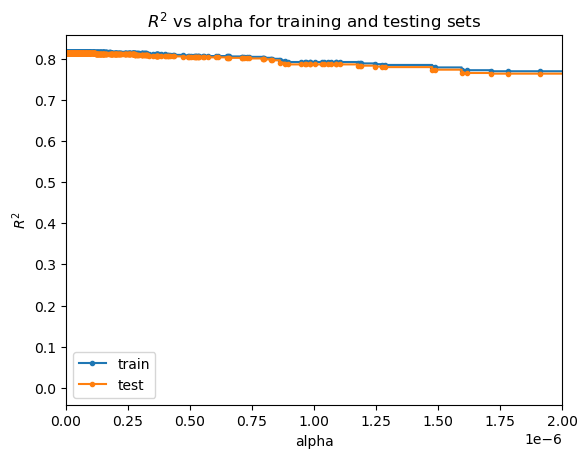

In [26]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.set_xlim(0.0, 0.2e-5)
ax.legend()
plt.show()

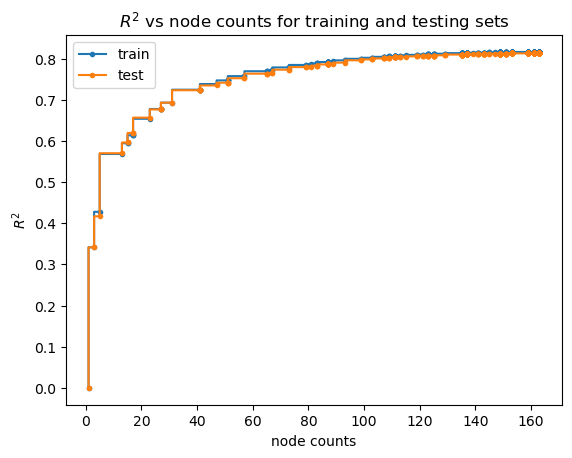

In [27]:
fig, ax = plt.subplots()
ax.set_xlabel("node counts")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs node counts for training and testing sets")
ax.plot(node_counts, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(node_counts, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

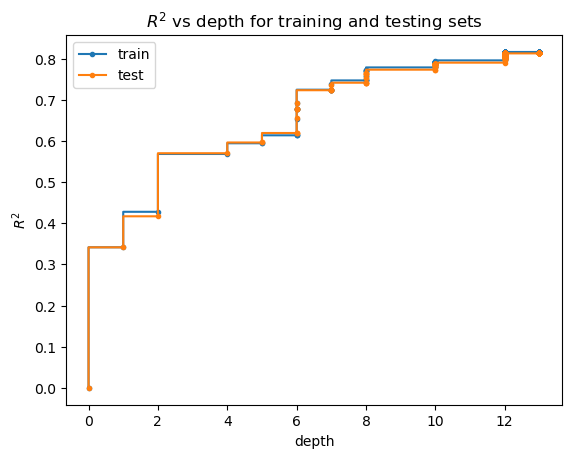

In [28]:
fig, ax = plt.subplots()
ax.set_xlabel("depth")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs depth for training and testing sets")
ax.plot(depth, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(depth, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [32]:
import numpy as np
import pandas as pd

In [8]:
# Create the grid of points
latitudes = np.linspace(40.75, 40.88, 290)
longitudes = np.linspace(-74.01, -73.86, 334)

In [24]:
# Create a meshgrid from latitudes and longitudes
Lon, Lat = np.meshgrid(longitudes, latitudes)

In [29]:
# Flatten the grid to create a list of points
points = np.vstack([Lon.flatten(), Lat.flatten()]).T

In [34]:
df_grid = pd.DataFrame()
df_grid['Longitude'] = points[:,0]
df_grid['Latitude'] = points[:,1]
df_grid.to_csv('../data/initial_datasets/longitude_latitude_grid_data.csv', index = False)